# 🌍 World Cup Analytics Project

## International Match Results Analysis

This notebook presents an exploratory data analysis focused on historical football data, aiming to identify competitive patterns, tournament trends, scoring behaviors, and strategic insights through visual analytics.

---

## 📌 Main Objectives

- Understand historical football trends
- Identify dominant national teams
- Analyze scoring and match outcome patterns
- Explore temporal evolution in football competitions
- Generate insights for future predictive modeling

---


In [ ]:
# 🎨 Visualization Style Configuration

import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.titlesize"] = 16
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["xtick.labelsize"] = 10
plt.rcParams["ytick.labelsize"] = 10

sns.set_theme(style="whitegrid", palette="viridis")


# 🌍 World Cup Predictor
## Exploratory Data Analysis (EDA)

---

# 🎯 Objective

The goal of this notebook is to explore the historical international football matches dataset,
understand data distribution, identify patterns, and prepare the foundation for feature engineering
and machine learning models.

---

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option("display.max_columns", None)

# Plot style
sns.set_style("whitegrid")

## 🗂️ Dataset Overview

Initial inspection and validation of the datasets used in this analysis.

In [2]:
results = pd.read_csv("../data/raw/results.csv")

# Display first rows
results.head()

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
0,1872-11-30,Scotland,England,0.0,0.0,Friendly,Glasgow,Scotland,False
1,1873-03-08,England,Scotland,4.0,2.0,Friendly,London,England,False
2,1874-03-07,Scotland,England,2.0,1.0,Friendly,Glasgow,Scotland,False
3,1875-03-06,England,Scotland,2.0,2.0,Friendly,London,England,False
4,1876-03-04,Scotland,England,3.0,0.0,Friendly,Glasgow,Scotland,False


In [3]:
results.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49353 entries, 0 to 49352
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   date        49353 non-null  object 
 1   home_team   49353 non-null  object 
 2   away_team   49353 non-null  object 
 3   home_score  49281 non-null  float64
 4   away_score  49281 non-null  float64
 5   tournament  49353 non-null  object 
 6   city        49353 non-null  object 
 7   country     49353 non-null  object 
 8   neutral     49353 non-null  bool   
dtypes: bool(1), float64(2), object(6)
memory usage: 3.1+ MB


## 📊 General Statistics

Exploring the scale and structure of the football datasets.

In [4]:
results.describe()

,home_score,away_score
count,49281.000000,49281.000000
mean,1.757371,1.182444
std,1.774995,1.402996
min,0.000000,0.000000
25%,1.000000,0.000000
50%,1.000000,1.000000
75%,2.000000,2.000000
max,31.000000,21.000000


In [5]:
results.isnull().sum()

date           0
home_team      0
away_team      0
home_score    72
away_score    72
tournament     0
city           0
country        0
neutral        0
dtype: int64

In [6]:
# ⚽ Total Matches

print(f"Total matches: {results.shape[0]}")

Total matches: 49353


In [7]:
# 🌍 Total National Teams

teams = pd.concat([results["home_team"], results["away_team"]]).unique()

print(f"Total teams: {len(teams)}")

Total teams: 336


## ⚽ Goal Scoring Analysis

Investigating scoring patterns and offensive tendencies.

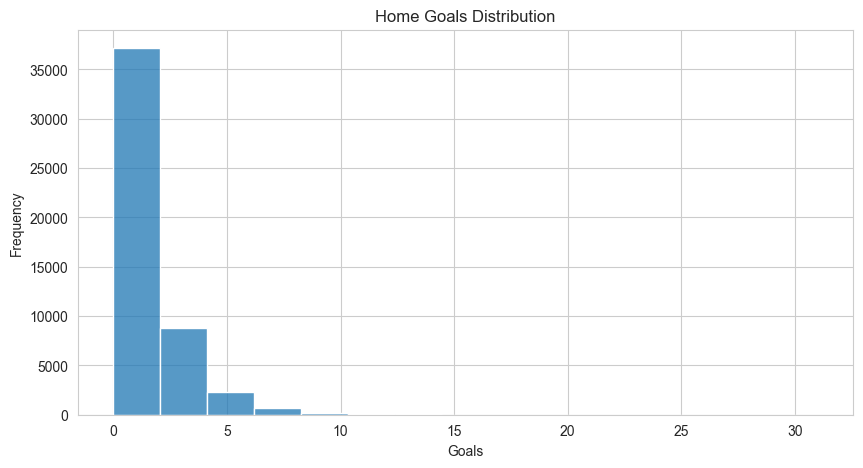

In [8]:
# 📊 Home Goals Distribution

plt.figure(figsize=(10, 5)
plt.grid(alpha=0.3))

sns.histplot(results["home_score"], bins=15)

plt.title("Home Goals Distribution")
plt.xlabel("Goals")
plt.ylabel("Frequency")

plt.show()

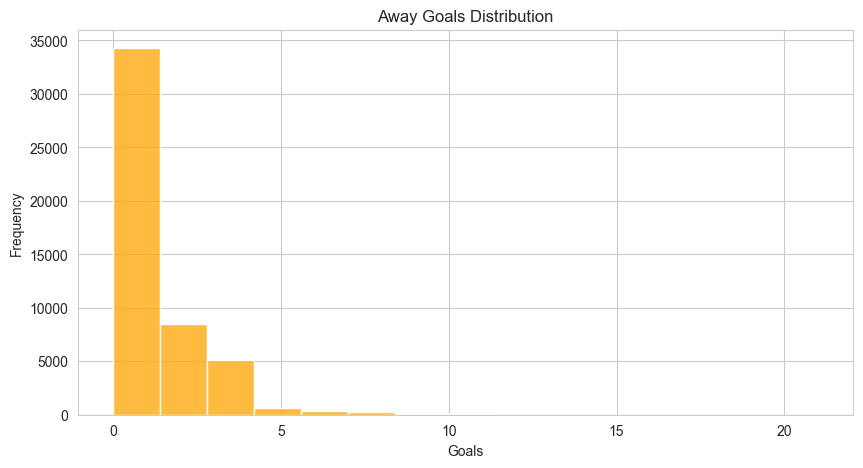

In [9]:
# 📊 Away Goals Distribution

plt.figure(figsize=(10, 5)
plt.grid(alpha=0.3))

sns.histplot(results["away_score"], bins=15, color="orange")

plt.title("Away Goals Distribution")
plt.xlabel("Goals")
plt.ylabel("Frequency")

plt.show()

## 🏆 Tournament Performance Analysis

Evaluating tournament outcomes and title distribution.

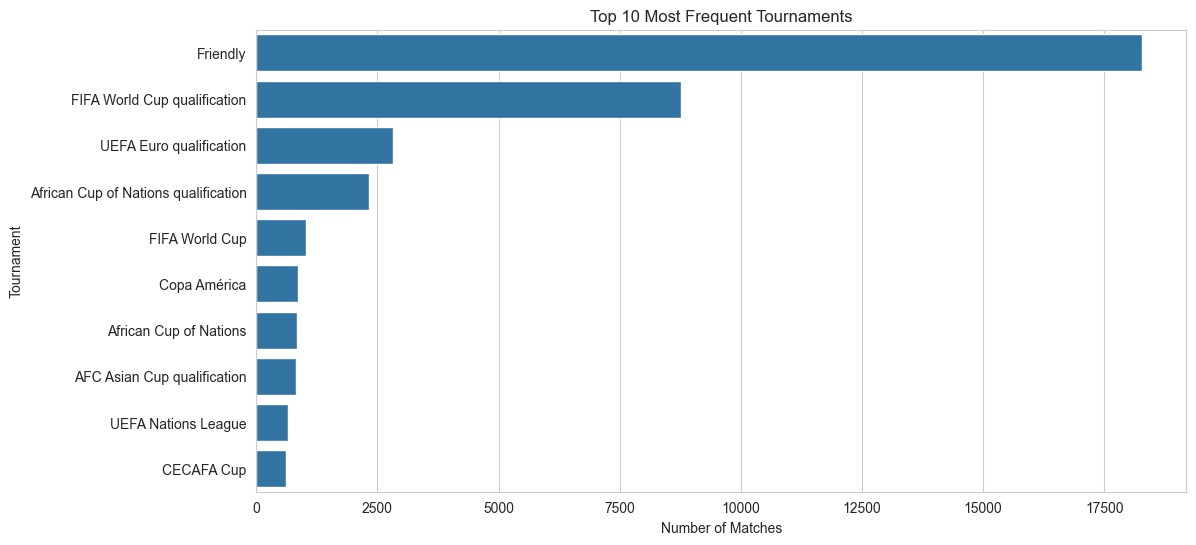

In [10]:
# 🏆 Most Frequent Tournaments

top_tournaments = results["tournament"].value_counts().head(10)

plt.figure(figsize=(12, 6)
plt.grid(alpha=0.3))

sns.barplot(
    x=top_tournaments.values,
    y=top_tournaments.index
)

plt.title("Top 10 Most Frequent Tournaments")
plt.xlabel("Number of Matches")
plt.ylabel("Tournament")

plt.show()

plt.tight_layout()

## 📈 Team Performance Analysis

Analyzing team efficiency, win rates, and competitive dominance.

In [11]:
# ⚔️ Match Result Creation

def get_result(row):
    if row["home_score"] > row["away_score"]:
        return "Home Win"
    elif row["home_score"] < row["away_score"]:
        return "Away Win"
    else:
        return "Draw"

results["match_result"] = results.apply(get_result, axis=1)

results["match_result"].value_counts()

match_result
Home Win    24149
Away Win    13928
Draw        11276
Name: count, dtype: int64

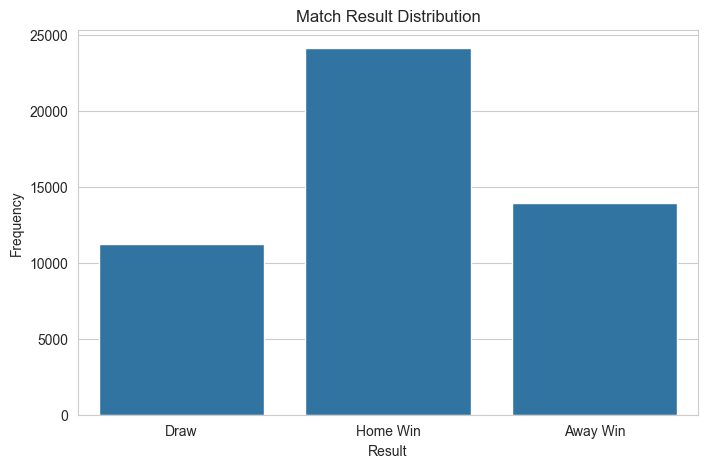

In [12]:
# 📊 Match Result Distribution

plt.figure(figsize=(8, 5)
plt.grid(alpha=0.3))

sns.countplot(
    data=results,
    x="match_result"
)

plt.title("Match Result Distribution")
plt.xlabel("Result")
plt.ylabel("Frequency")

plt.show()

# 🎯 Analytical Conclusion


The dataset provides a comprehensive historical record of international football matches,
covering more than 49,000 games across multiple tournaments, countries, and eras.

The exploratory analysis revealed several important patterns:
- Most football matches end with a relatively low number of goals.
- Home teams tend to perform better than away teams, suggesting the presence of home advantage.
- Friendly matches and qualification tournaments represent a large portion of the dataset.
- The data contains broad international coverage, including 336 national teams.

Additionally, the dataset shows strong data quality, with very few missing values,
making it highly suitable for machine learning and predictive modeling applications.

These findings establish a strong foundation for the next stages of the project,
including feature engineering, predictive modeling, and tournament simulation.


---

In [13]:
# 🏟️ Home Advantage Statistics

home_win_rate = (
    results["match_result"]
    .value_counts(normalize=True) * 100
)

home_win_rate

match_result
Home Win    48.931169
Away Win    28.221182
Draw        22.847649
Name: proportion, dtype: float64

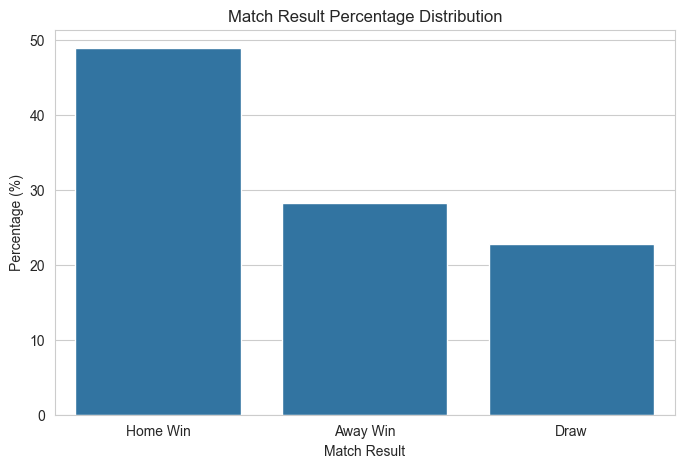

In [14]:
# 📊 Match Result Percentage Distribution

plt.figure(figsize=(8,5)
plt.grid(alpha=0.3))

sns.barplot(
    x=home_win_rate.index,
    y=home_win_rate.values
)

plt.title("Match Result Percentage Distribution")
plt.xlabel("Match Result")
plt.ylabel("Percentage (%)")

plt.show()

plt.tight_layout()

In [15]:
# 🏆 Winner Column Creation

def get_winner(row):
    if row["home_score"] > row["away_score"]:
        return row["home_team"]
    
    elif row["home_score"] < row["away_score"]:
        return row["away_team"]
    
    else:
        return "Draw"

results["winner"] = results.apply(get_winner, axis=1)

results[["home_team", "away_team", "winner"]].head()

,home_team,away_team,winner
0,Scotland,England,Draw
1,England,Scotland,England
2,Scotland,England,Scotland
3,England,Scotland,Draw
4,Scotland,England,Scotland


In [16]:
# 🌍 Top Winning Countries

top_winners = (
    results[results["winner"] != "Draw"]["winner"]
    .value_counts()
    .head(10)
)

top_winners

winner
Brazil         671
England        623
Germany        598
Argentina      590
Sweden         541
South Korea    537
Mexico         513
France         476
Italy          475
Hungary        470
Name: count, dtype: int64

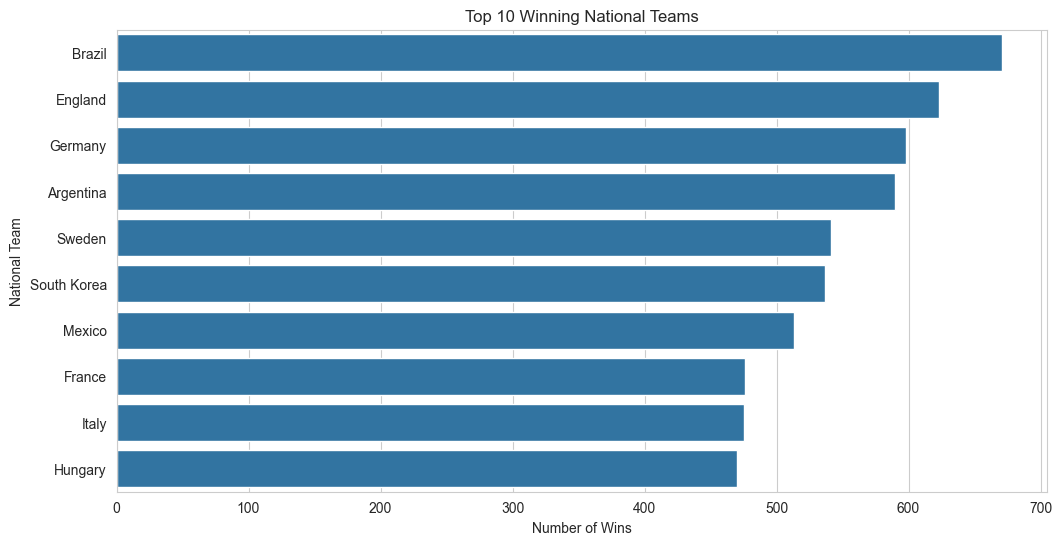

In [17]:
# 📊 Top Winning Countries Visualization

plt.figure(figsize=(12,6)
plt.grid(alpha=0.3))

sns.barplot(
    x=top_winners.values,
    y=top_winners.index
)

plt.title("Top 10 Winning National Teams")
plt.xlabel("Number of Wins")
plt.ylabel("National Team")

plt.show()

plt.tight_layout()

# 📌 Key Insights


- Home wins represent approximately 49% of all match outcomes.
- Away wins occur significantly less frequently, accounting for around 28% of matches.
- Draws represent approximately 23% of the results.

These findings provide strong evidence of a home advantage effect in international football,
suggesting that teams tend to perform better when playing in their home country.


---

In [18]:
# ⚽ Total Matches per Team

home_matches = results["home_team"].value_counts()
away_matches = results["away_team"].value_counts()

total_matches_per_team = (
    home_matches.add(away_matches, fill_value=0)
)

total_matches_per_team.head()

Abkhazia        33.0
Afghanistan    144.0
Albania        396.0
Alderney       135.0
Algeria        618.0
Name: count, dtype: float64

In [19]:
# 🏆 Total Wins per Team

wins_per_team = (
    results[results["winner"] != "Draw"]["winner"]
    .value_counts()
)

wins_per_team.head()

winner
Brazil       671
England      623
Germany      598
Argentina    590
Sweden       541
Name: count, dtype: int64

In [20]:
# 📊 Win Rate Calculation

win_rate = (
    wins_per_team / total_matches_per_team
) * 100

win_rate = (
    win_rate
    .sort_values(ascending=False)
)

win_rate.head(10)

Asturias          100.000000
Elba Island       100.000000
Surrey            100.000000
Maule Sur         100.000000
Kurdistan          80.000000
Canary Islands     75.000000
Yorkshire          71.428571
County of Nice     66.666667
Biafra             66.666667
Franconia          66.666667
Name: count, dtype: float64

In [21]:
# ⚽ Minimum Matches Filter

minimum_matches = 100

valid_teams = total_matches_per_team[
    total_matches_per_team >= minimum_matches
].index

filtered_win_rate = win_rate[
    win_rate.index.isin(valid_teams)
]

filtered_win_rate = (
    filtered_win_rate
    .sort_values(ascending=False)
)

filtered_win_rate.head(10)

Jersey       65.106383
Brazil       63.242224
Guernsey     60.416667
Spain        58.673469
Germany      57.889642
England      57.103575
Iran         56.677524
Argentina    55.191768
Tahiti       54.132231
Italy        53.310887
Name: count, dtype: float64

# 📌 Key Insights


- Initial win rate calculations revealed several teams with extremely high percentages.
- However, many of these teams had played only a very small number of matches.
- A minimum match threshold was applied to reduce statistical bias and improve reliability.
- This filtering process helps create more realistic and meaningful performance comparisons.


---

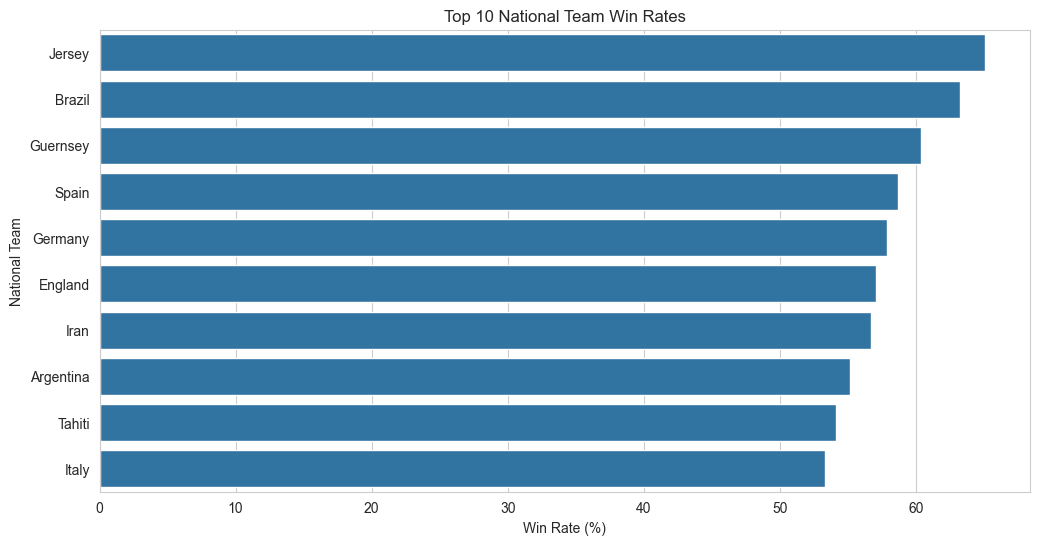

In [22]:
# 📊 Top National Team Win Rates

top_filtered_win_rate = filtered_win_rate.head(10)

plt.figure(figsize=(12,6)
plt.grid(alpha=0.3))

sns.barplot(
    x=top_filtered_win_rate.values,
    y=top_filtered_win_rate.index
)

plt.title("Top 10 National Team Win Rates")
plt.xlabel("Win Rate (%)")
plt.ylabel("National Team")

plt.show()

plt.tight_layout()

## 📅 Temporal Evolution Analysis

Understanding how football evolved across different eras.

In [23]:
# 📅 Date Conversion

results["date"] = pd.to_datetime(results["date"])

results["year"] = results["date"].dt.year

results[["date", "year"]].head()

,date,year
0,1872-11-30,1872
1,1873-03-08,1873
2,1874-03-07,1874
3,1875-03-06,1875
4,1876-03-04,1876


In [24]:
# ⚽ Total Goals Per Match

results["total_goals"] = (
    results["home_score"] +
    results["away_score"]
)

results[["home_score", "away_score", "total_goals"]].head()

,home_score,away_score,total_goals
0,0.0,0.0,0.0
1,4.0,2.0,6.0
2,2.0,1.0,3.0
3,2.0,2.0,4.0
4,3.0,0.0,3.0


In [25]:
# 📊 Average Goals Per Year

goals_per_year = (
    results.groupby("year")["total_goals"]
    .mean()
)

goals_per_year.head()

year
1872    0.0
1873    6.0
1874    3.0
1875    4.0
1876    3.5
Name: total_goals, dtype: float64

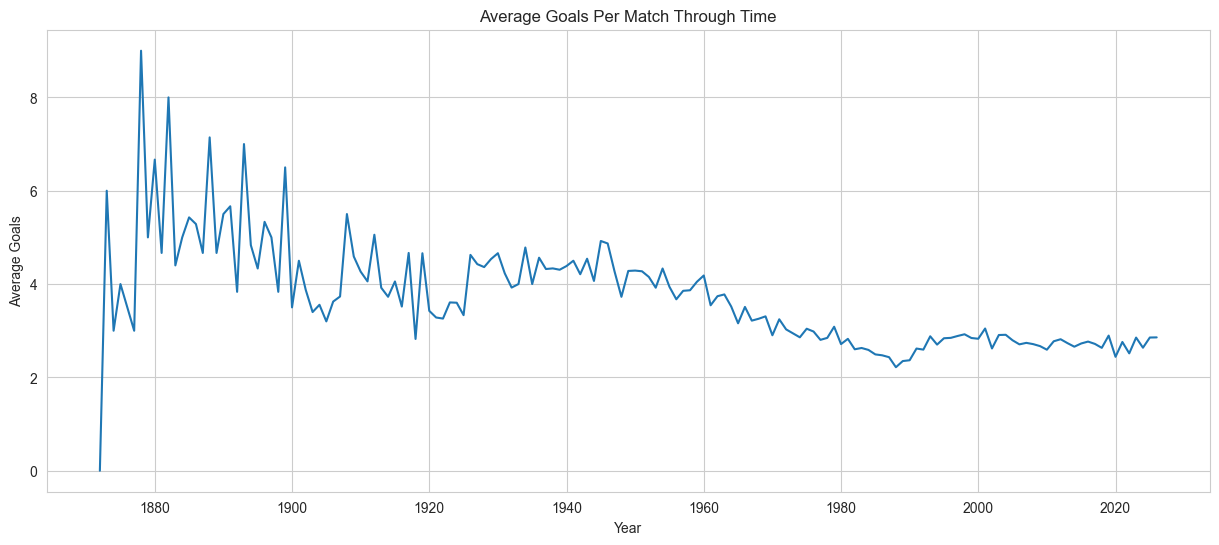

In [26]:
# 📈 Goals Evolution Through Time

plt.figure(figsize=(15,6)
plt.grid(alpha=0.3))

sns.lineplot(
    x=goals_per_year.index,
    y=goals_per_year.values
)

plt.title("Average Goals Per Match Through Time")
plt.xlabel("Year")
plt.ylabel("Average Goals")

plt.show()

In [27]:
# 🌍 Match Frequency Through Time

matches_per_year = (
    results["year"]
    .value_counts()
    .sort_index()
)

matches_per_year.head()

year
1872    1
1873    1
1874    1
1875    1
1876    2
Name: count, dtype: int64

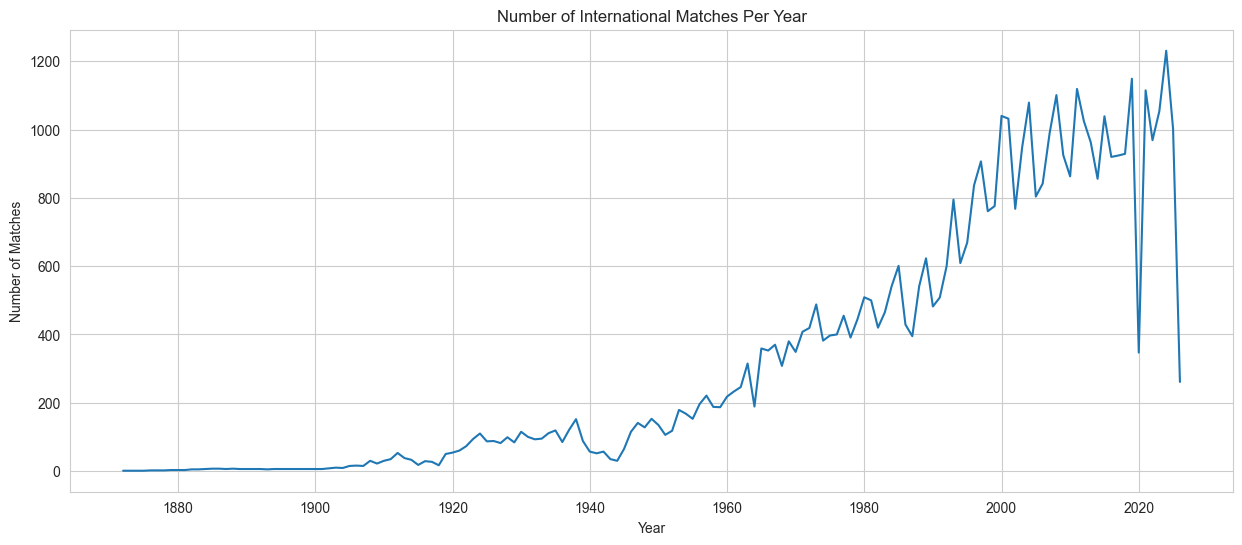

In [28]:
# 📊 Matches Played Per Year

plt.figure(figsize=(15,6)
plt.grid(alpha=0.3))

sns.lineplot(
    x=matches_per_year.index,
    y=matches_per_year.values
)

plt.title("Number of International Matches Per Year")
plt.xlabel("Year")
plt.ylabel("Number of Matches")

plt.show()

# 🎯 Analytical Conclusion


The temporal analysis revealed important historical patterns in international football.

The evolution of goals per match suggests that football became progressively more balanced and defensively organized over time. Earlier decades presented higher scoring volatility, while modern football tends to maintain more stable scoring averages between 2 and 3 goals per match.

Additionally, the number of international matches increased dramatically throughout history, especially after the mid-20th century. This growth likely reflects the global expansion of football competitions, FIFA tournaments, qualification systems, and international participation.

The analysis also highlighted important considerations for future modeling, such as:
- small sample size bias in early years,
- temporal inconsistencies in incomplete recent seasons,
- and the increasing competitiveness of modern football.

Overall, these findings provide valuable insights into the historical evolution of international football and establish a strong foundation for future feature engineering and predictive modeling stages of the project.


---

## 🏟️ Neutral Venue Impact

Assessing the influence of neutral venues on match outcomes.

In [29]:
# 🏟️ Neutral Match Distribution

results["neutral"].value_counts()

neutral
False    36286
True     13067
Name: count, dtype: int64

In [30]:
# 📊 Neutral Match Percentage

neutral_percentage = (
    results["neutral"]
    .value_counts(normalize=True) * 100
)

neutral_percentage

neutral
False    73.523393
True     26.476607
Name: proportion, dtype: float64

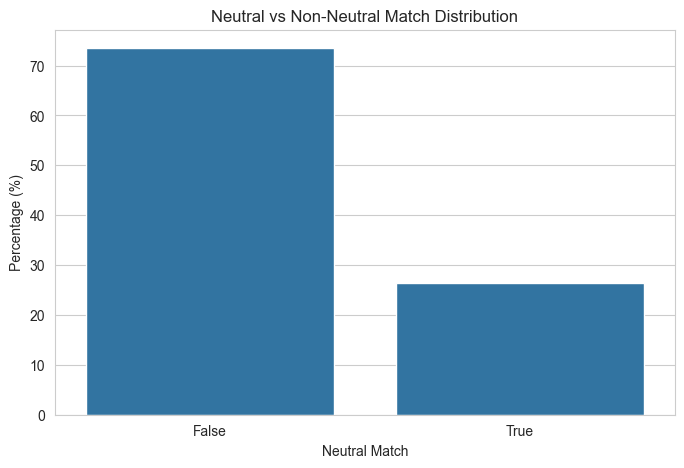

In [31]:
# 📈 Neutral vs Non-Neutral Matches

plt.figure(figsize=(8,5)
plt.grid(alpha=0.3))

sns.barplot(
    x=neutral_percentage.index.astype(str),
    y=neutral_percentage.values
)

plt.title("Neutral vs Non-Neutral Match Distribution")
plt.xlabel("Neutral Match")
plt.ylabel("Percentage (%)")

plt.show()

plt.tight_layout()

In [32]:
# ⚽ Match Results in Neutral Matches

neutral_results = (
    results[results["neutral"] == True]["match_result"]
    .value_counts(normalize=True) * 100
)

neutral_results

match_result
Home Win    43.958062
Away Win    33.259356
Draw        22.782582
Name: proportion, dtype: float64

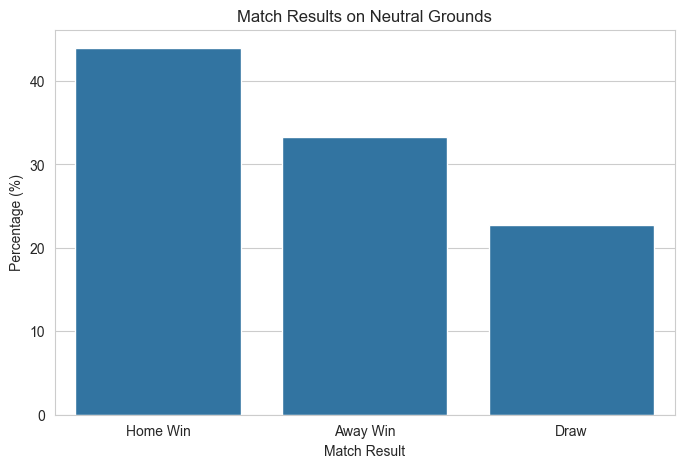

In [33]:
# 📈 Neutral Match Results Distribution

plt.figure(figsize=(8,5)
plt.grid(alpha=0.3))

sns.barplot(
    x=neutral_results.index,
    y=neutral_results.values
)

plt.title("Match Results on Neutral Grounds")
plt.xlabel("Match Result")
plt.ylabel("Percentage (%)")

plt.show()

plt.tight_layout()

In [34]:
# 📊 Comparing Neutral and Non-Neutral Matches

non_neutral_results = (
    results[results["neutral"] == False]["match_result"]
    .value_counts(normalize=True) * 100
)

comparison_df = pd.DataFrame({
    "Neutral": neutral_results,
    "Non-Neutral": non_neutral_results
})

comparison_df

,Neutral,Non-Neutral
match_result,,
Home Win,43.958062,50.722042
Away Win,33.259356,26.406879
Draw,22.782582,22.871080


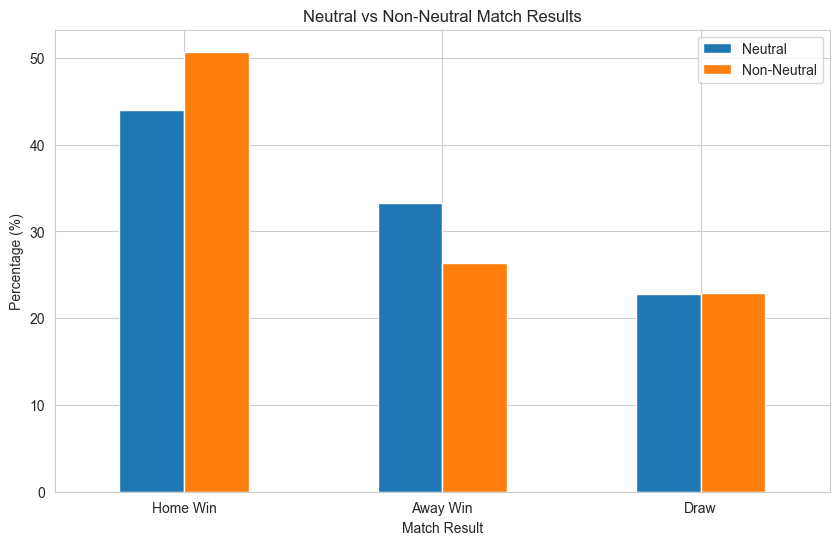

In [35]:
# 📈 Neutral vs Non-Neutral Comparison

comparison_df.plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Neutral vs Non-Neutral Match Results")
plt.xlabel("Match Result")
plt.ylabel("Percentage (%)")

plt.xticks(rotation=0)

plt.show()

# 📌 Key Insights


- Non-neutral matches show a strong home advantage effect, with home teams winning approximately half of all matches.
- In neutral matches, the difference between home and away victories becomes considerably smaller.
- Draw percentages remain relatively stable across both neutral and non-neutral conditions.
- These findings suggest that playing at home provides a meaningful competitive advantage in international football.
- Since many World Cup matches occur on neutral grounds, this factor may become highly relevant for predictive modeling.


---